In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
from tensorflow.keras.datasets import mnist

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print("Original x_train shape:", x_train.shape)
print("Original x_test shape:", x_test.shape)
print("Original y_train shape:", y_train.shape)
print("Original y_test shape:", y_test.shape)

Original x_train shape: (60000, 28, 28)
Original x_test shape: (10000, 28, 28)
Original y_train shape: (60000,)
Original y_test shape: (10000,)


In [ ]:
x_train = x_train.astype('float32')/255.0
x_test = x_test.astype('float32')/255.0

In [ ]:
x_train_img = x_train.reshape(-1, 28, 28, 1)
x_test_img = x_test.reshape(-1, 28, 28, 1)

In [ ]:
x_train_img.shape

(60000, 28, 28, 1)

In [ ]:
x_test_img.shape

(10000, 28, 28, 1)

In [ ]:
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

## **Perceptron**

In [ ]:
perceptron = Sequential([
    Flatten(input_shape = (28,28,1)),
    Dense(10, activation = 'softmax')
])

In [ ]:
perceptron.compile(optimizer='sgd', loss = "categorical_crossentropy", metrics = ['accuracy'])

In [ ]:
history_perceptron = perceptron.fit(x_train_img, y_train_cat, epochs = 20, batch_size = 32, validation_data = (x_test_img,y_test_cat),verbose=1)


Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8153 - loss: 0.7762 - val_accuracy: 0.8813 - val_loss: 0.4800
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8806 - loss: 0.4560 - val_accuracy: 0.8966 - val_loss: 0.3996
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8917 - loss: 0.4034 - val_accuracy: 0.9019 - val_loss: 0.3673
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8982 - loss: 0.3769 - val_accuracy: 0.9069 - val_loss: 0.3478
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9012 - loss: 0.3602 - val_accuracy: 0.9088 - val_loss: 0.3365
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9037 - loss: 0.3484 - val_accuracy: 0.9097 - val_loss: 0.3271
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9058 - loss: 0.3394 - val_accuracy: 0.9115 - val_loss: 0.3204
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9078 - loss: 0.3322 - 

In [ ]:
acc_perceptron = history_perceptron.history['accuracy'][1]
val_acc_perceptron = history_perceptron.history['val_accuracy'][1]

In [ ]:
print(acc_perceptron)
print(val_acc_perceptron)

0.8805999755859375
0.8966000080108643


# ANN

In [ ]:
ann = Sequential([
    Flatten(input_shape = (28,28,1)),
    Dense(128, activation = 'relu'),
    Dense(64, activation = 'relu'),
    Dense(32, activation = 'relu'),
    Dense(10, activation = 'softmax')
])

In [ ]:
ann.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
ann_history = ann.fit(x_train_img, y_train_cat, epochs = 5, batch_size = 32,validation_data=(x_test_img,y_test_cat), verbose= 1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9261 - loss: 0.2490 - val_accuracy: 0.9627 - val_loss: 0.1259
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9686 - loss: 0.1039 - val_accuracy: 0.9695 - val_loss: 0.0990
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9773 - loss: 0.0738 - val_accuracy: 0.9720 - val_loss: 0.0892
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9814 - loss: 0.0574 - val_accuracy: 0.9697 - val_loss: 0.1018
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9853 - loss: 0.0463 - val_accuracy: 0.9764 - val_loss: 0.0771


In [ ]:
acc_ann = ann_history.history['accuracy'][1]
val_acc_ann = ann_history.history['val_accuracy'][1]

In [ ]:
print("ANN Aacuracy: ",acc_ann)
print("Validation Accuracy: ",val_acc_ann)

ANN Aacuracy:  0.9685999751091003
Validation Accuracy:  0.9695000052452087


# **CNN**

In [ ]:
x_train_cnn = x_train_img
y_train_cnn = y_train_cat
x_test_cnn = x_test_img
y_test_cnn = y_test_cat

In [ ]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3,3), activation = 'relu', input_shape = (28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size = (2,2)),
    Flatten(),
    Dense(128, activation = 'relu'),
    Dropout(0.5),
    Dense(10, activation = 'softmax')
])

In [ ]:
cnn.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
cnn_history = cnn.fit(x_train_cnn,y_train_cnn, epochs = 5, batch_size = 32, validation_data = (x_test_cnn,y_test_cnn))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 32ms/step - accuracy: 0.9574 - loss: 0.1392 - val_accuracy: 0.9848 - val_loss: 0.0444
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9769 - loss: 0.0772 - val_accuracy: 0.9869 - val_loss: 0.0378
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.9830 - loss: 0.0564 - val_accuracy: 0.9905 - val_loss: 0.0272
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 33ms/step - accuracy: 0.9860 - loss: 0.0458 - val_accuracy: 0.9926 - val_loss: 0.0220
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9888 - loss: 0.0367 - val_accuracy: 0.9915 - val_loss: 0.0255


In [ ]:
cnn_ann = cnn_history.history['accuracy'][1]
val_acc_cnn = cnn_history.history['val_accuracy'][1]

In [ ]:
print("CNN Accuracy: ",cnn_ann)
print("Validation Accuracy: ",val_acc_cnn)

CNN Accuracy:  0.9768666625022888
Validation Accuracy:  0.9868999719619751


## Training and Validation Performance Visualizations

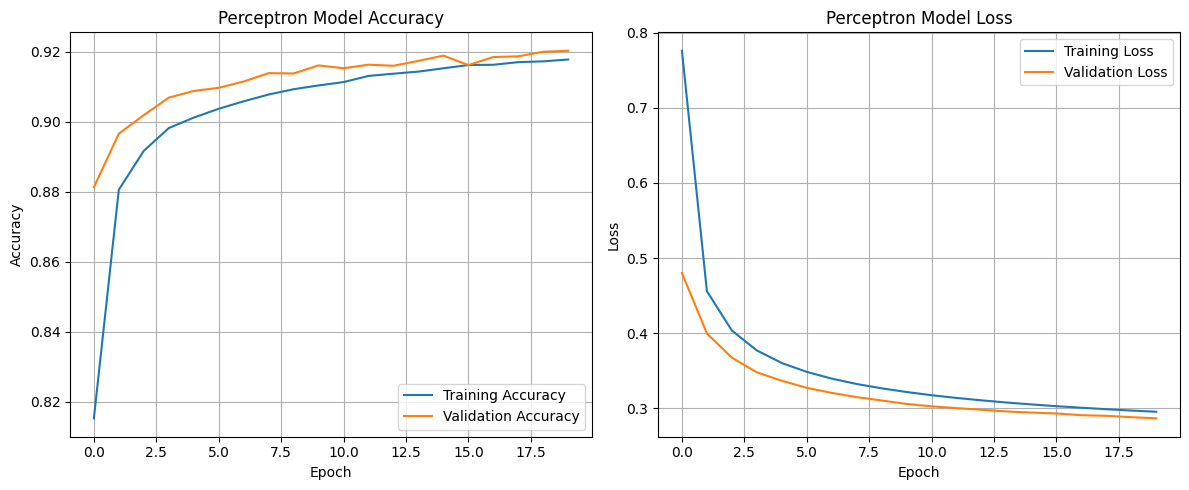

In [ ]:
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_perceptron.history['accuracy'], label='Training Accuracy')
plt.plot(history_perceptron.history['val_accuracy'], label='Validation Accuracy')
plt.title('Perceptron Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_perceptron.history['loss'], label='Training Loss')
plt.plot(history_perceptron.history['val_loss'], label='Validation Loss')
plt.title('Perceptron Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

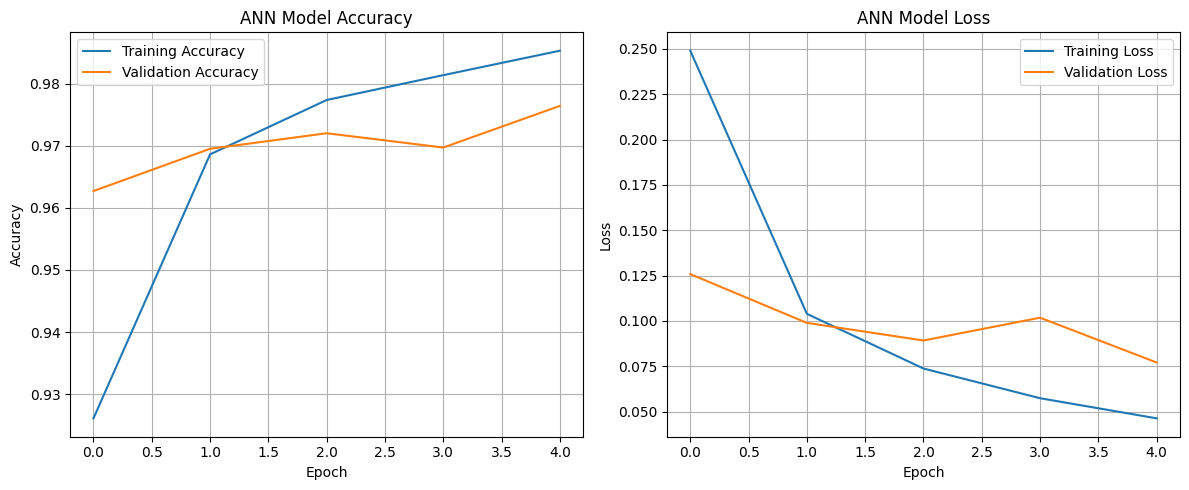

In [ ]:
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(ann_history.history['accuracy'], label='Training Accuracy')
plt.plot(ann_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('ANN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(ann_history.history['loss'], label='Training Loss')
plt.plot(ann_history.history['val_loss'], label='Validation Loss')
plt.title('ANN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

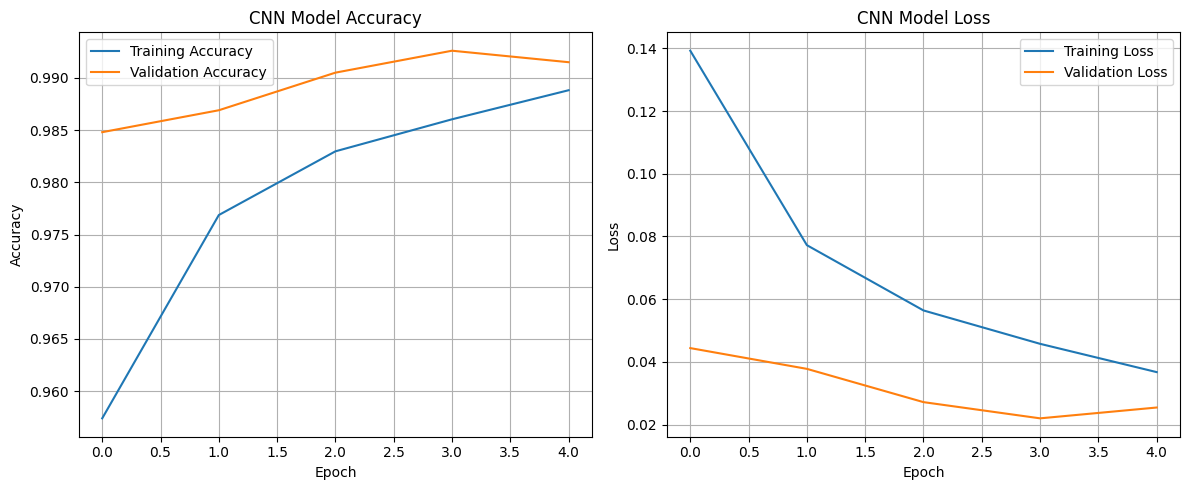

In [ ]:
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'], label='Training Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')
plt.title('CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## **Model Comparison: Validation Accuracy**

Validation Accuracy Comparison:


,Model,Validation Accuracy
0,Perceptron,0.8966
1,ANN,0.9695
2,CNN,0.9869


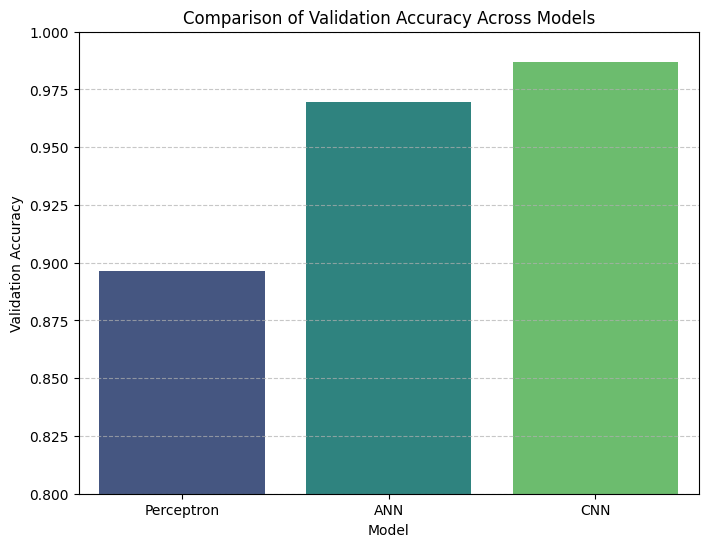

In [ ]:
comparison_df = pd.DataFrame({
    'Model': ['Perceptron', 'ANN', 'CNN'],
    'Validation Accuracy': [val_acc_perceptron, val_acc_ann, val_acc_cnn]
})

# Display the comparison table
print("Validation Accuracy Comparison:")
display(comparison_df)

# Create a bar plot for visualization
plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='Validation Accuracy', data=comparison_df, palette='viridis')
plt.title('Comparison of Validation Accuracy Across Models')
plt.xlabel('Model')
plt.ylabel('Validation Accuracy')
plt.ylim(0.8, 1.0) # Set appropriate y-axis limits for accuracy
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## **Model Testing and Prediction**

In [ ]:
def predict_digit_with_all_models(image_data):
    # Ensure image_data is in the correct format (28, 28, 1) and normalized
    # The models were trained on (28, 28, 1) images, so reshape if needed.
    # Assuming image_data is a single image, reshape for batch prediction.
    processed_image = image_data.reshape(1, 28, 28, 1)

    # Perceptron prediction
    perceptron_pred = perceptron.predict(processed_image)
    perceptron_digit = np.argmax(perceptron_pred)

    # ANN prediction
    ann_pred = ann.predict(processed_image)
    ann_digit = np.argmax(ann_pred)

    # CNN prediction
    cnn_pred = cnn.predict(processed_image)
    cnn_digit = np.argmax(cnn_pred)

    return perceptron_digit, ann_digit, cnn_digit

Let's pick a few random images from the test set to demonstrate the prediction function.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


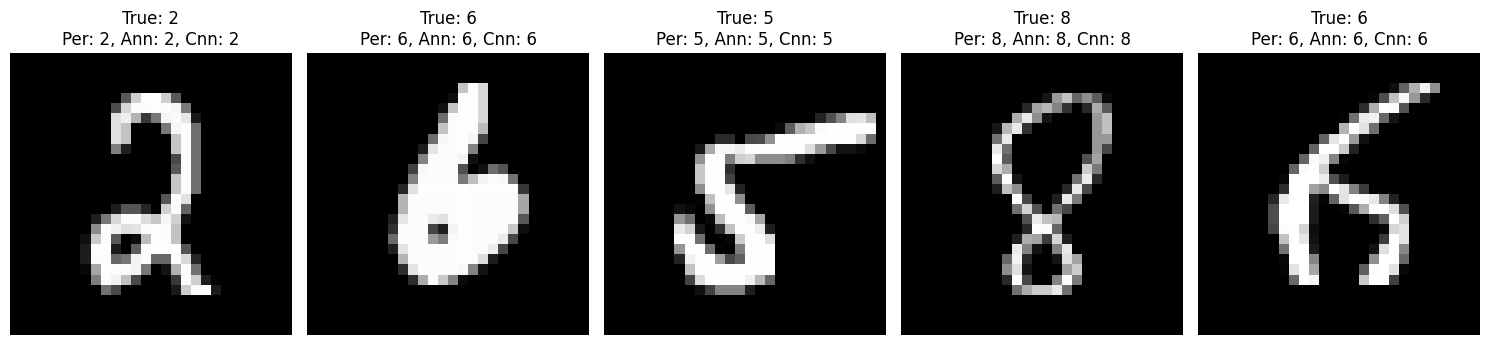

In [ ]:
num_samples = 5 # Number of images to test
random_indices = np.random.choice(len(x_test_img), num_samples, replace=False)

plt.figure(figsize=(15, 5))
for i, idx in enumerate(random_indices):
    image = x_test_img[idx]
    true_label = y_test[idx]

    perceptron_p, ann_p, cnn_p = predict_digit_with_all_models(image)

    plt.subplot(1, num_samples, i + 1)
    plt.imshow(image.reshape(28, 28), cmap='gray')
    plt.title(f"True: {true_label}\nPer: {perceptron_p}, Ann: {ann_p}, Cnn: {cnn_p}")
    plt.axis('off')
plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


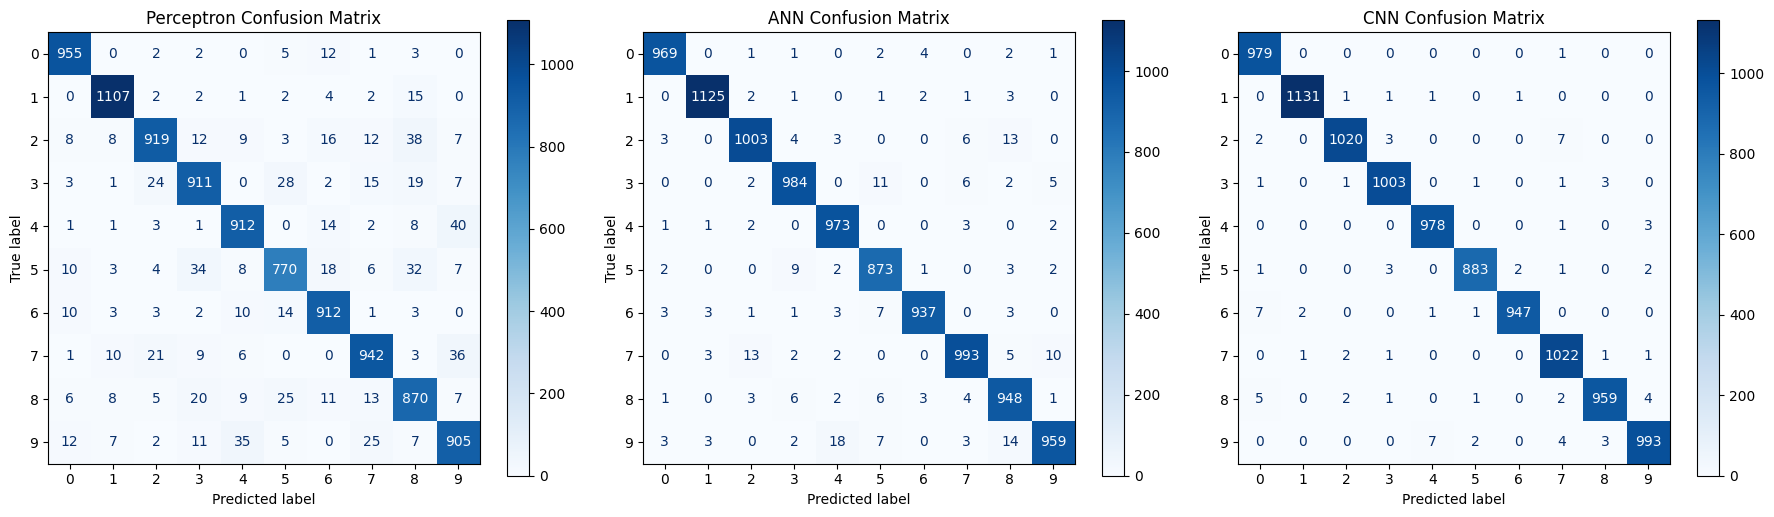

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions for all models on the test set
y_pred_perceptron = np.argmax(perceptron.predict(x_test_img), axis=1)
y_pred_ann = np.argmax(ann.predict(x_test_img), axis=1)
y_pred_cnn = np.argmax(cnn.predict(x_test_img), axis=1)

# True labels for the test set
y_true = y_test

plt.figure(figsize=(18, 5))

# Perceptron Confusion Matrix
plt.subplot(1, 3, 1)
cm_perceptron = confusion_matrix(y_true, y_pred_perceptron)
disp_perceptron = ConfusionMatrixDisplay(confusion_matrix=cm_perceptron, display_labels=range(10))
disp_perceptron.plot(cmap=plt.cm.Blues, ax=plt.gca())
plt.title('Perceptron Confusion Matrix')

# ANN Confusion Matrix
plt.subplot(1, 3, 2)
cm_ann = confusion_matrix(y_true, y_pred_ann)
disp_ann = ConfusionMatrixDisplay(confusion_matrix=cm_ann, display_labels=range(10))
disp_ann.plot(cmap=plt.cm.Blues, ax=plt.gca())
plt.title('ANN Confusion Matrix')

# CNN Confusion Matrix
plt.subplot(1, 3, 3)
cm_cnn = confusion_matrix(y_true, y_pred_cnn)
disp_cnn = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=range(10))
disp_cnn.plot(cmap=plt.cm.Blues, ax=plt.gca())
plt.title('CNN Confusion Matrix')

plt.tight_layout()
plt.show()

In [ ]:
cnn.save("digit_model.h5")